Buscando dataset en: C:\Users\loren\Downloads\TESIS\Multclass\Dataset_Multiclass\irisMn.mat
Dataset cargado correctamente. Clases detectadas: [1 2 3]
Entrenando modelo All-SVM. Por favor espera...

======================= RESULTADOS =======================
Modelo      : All-SVM (Weston-Watkins)
BACCU       : 0.9600
Accuracy    : 0.9600
Tiempo      : 0.7140 segundos



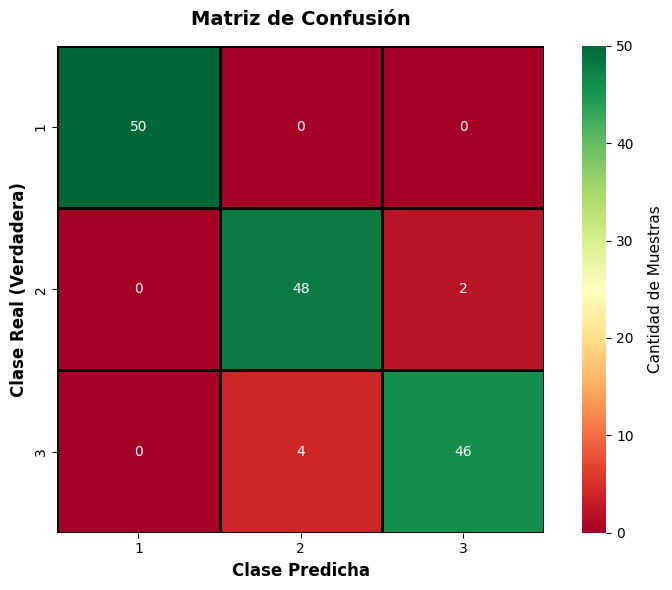

In [5]:
# =========================================================
# Ejecución de All-SVM y Matriz de Confusión Multiclase
# =========================================================
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import time
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

# ====================================================================
# 1. Definición del Modelo Multiclase All-SVM (Weston-Watkins)
# ====================================================================
def MultiSVM_WW_cvx(Xtr, Ytr, Xte, Yte, FunPara, T):
    C = FunPara.get('c', 1.0)
    m, n = Xtr.shape
    classes = np.unique(Ytr)
    
    W = cp.Variable((n, T))
    b = cp.Variable(T)
    Xi = cp.Variable((m, T))
    
    objective = cp.Minimize(0.5 * cp.sum_squares(W) + C * cp.sum(Xi))
    
    # Restricción sum(b) == 0 para anclar el hiperplano centralmente
    constraints = [
        Xi >= 0,
        cp.sum(b) == 0  
    ]
    
    for i in range(m):
        yi = np.where(classes == Ytr[i])[0][0] 
        constraints.append(Xi[i, yi] == 0)
        
        for k in range(T):
            if k != yi:
                constraints.append(
                    Xtr[i, :] @ W[:, yi] + b[yi] - (Xtr[i, :] @ W[:, k] + b[k]) >= 2 - Xi[i, k]
                )
                
    prob = cp.Problem(objective, constraints)
    prob.solve() 
    
    if W.value is None:
        raise ValueError(f"El solver falló al resolver All-SVM (Status: {prob.status}).")
    
    W_val = W.value
    b_val = b.value
    
    # Predicción (Asignar la clase con el mayor valor de la función de decisión)
    Fk_Test = Xte @ W_val + b_val
    pred_indices = np.argmax(Fk_Test, axis=1)
    pred_classes = classes[pred_indices]  # Recupera las etiquetas reales (ej. 1, 2, 3)
    
    bal_accu = balanced_accuracy_score(Yte, pred_classes)
    accu = accuracy_score(Yte, pred_classes)
    
    Sol = {'W': W_val, 'Bias': b_val, 'Xi': Xi.value, 'Prediction': pred_classes} 
    return bal_accu, accu, Sol

# ====================================================================
# 2. Función para graficar la Matriz de Confusión
# ====================================================================
def graficar_matriz_confusion(y_true, y_pred, titulo="Matriz de Confusión"):
    clases = np.unique(np.concatenate((y_true, y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    
    plt.figure(figsize=(8, 6))
    
    # cmap='RdYlGn' (Rojo = Errores/Ceros, Verde = Aciertos)
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', cbar=True, 
                     square=True, linewidths=1, linecolor='black',
                     xticklabels=clases, yticklabels=clases)
    
    plt.title(titulo, fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Clase Predicha', fontsize=12, fontweight='bold')
    plt.ylabel('Clase Real (Verdadera)', fontsize=12, fontweight='bold')
    
    # Ajustar la leyenda de la barra de color
    cbar = ax.collections[0].colorbar
    cbar.set_label('Cantidad de Muestras', fontsize=11, labelpad=10)
    
    plt.tight_layout()
    plt.show()

# ====================================================================
# 3. Carga de Datos y Ejecución
# ====================================================================
# Ruta directa al dataset multiclase Iris
ruta_dataset = r"C:\Users\loren\Downloads\TESIS\Multclass\Dataset_Multiclass\irisMn.mat"
print(f"Buscando dataset en: {ruta_dataset}")

try:
    # Cargar datos
    data = sio.loadmat(ruta_dataset)
    X = data['X']
    Y = data['Y'].flatten().astype(int)
    
    classes = np.unique(Y)
    T = len(classes)
    print(f"Dataset cargado correctamente. Clases detectadas: {classes}")
    
    # Configuración de Parámetros (usando los que tenías para All-SVM)
    FunPara = {'kerfPara': {'type': 'lin'}, 'c': 2**(-3)}
    
    # Entrenar y Predecir
    print("Entrenando modelo All-SVM. Por favor espera...")
    t0 = time.time()
    
    # En este caso usamos X e Y tanto para Train como para Test
    bal_accu, accu, Sol = MultiSVM_WW_cvx(X, Y, X, Y, FunPara, T)
    t_final = time.time() - t0
    
    # Imprimir Resultados Numéricos
    print("\n======================= RESULTADOS =======================")
    print(f"Modelo      : All-SVM (Weston-Watkins)")
    print(f"BACCU       : {bal_accu:.4f}")
    print(f"Accuracy    : {accu:.4f}")
    print(f"Tiempo      : {t_final:.4f} segundos")
    print("==========================================================\n")
    
    # Extraer las predicciones calculadas por el modelo
    Predicciones = Sol['Prediction']
    
    # Graficar visualmente la Matriz de Confusión
    graficar_matriz_confusion(Y, Predicciones, titulo="Matriz de Confusión")

except FileNotFoundError:
    print("ERROR: No se encontró el archivo. Verifica que 'irisMn.mat' exista en la carpeta 'Dataset_Multiclass'.")